# Spatially Transformed Adversarial Examples: Warping Instead of Adding Noise

Every attack elsewhere in this repo, whitebox or blackbox, physical, universal, or one-pixel, works the same way at the pixel level: it *adds* something to a pixel's color value, then bounds how much or how many pixels that addition can touch. stAdv (Xiao et al., 2018, *"Spatially Transformed Adversarial Examples"*) does something categorically different: it never changes a single pixel's color. Instead, it learns a smooth 2D displacement field and **moves** pixels to new positions via bilinear resampling, the same warping operation a Spatial Transformer Network (Jaderberg et al., 2015) uses, run in reverse to *break* a classifier instead of helping one.

The perceptual argument is different too: an $L_\infty$-bounded perturbation is imperceptible because each individual pixel barely changes; a spatial warp is imperceptible (when it works) because *locally* everything still looks like the same object, only subtly stretched or shifted, the way a photo looks after a very mild lens distortion. This notebook implements the warp from scratch (a differentiable bilinear sampler, since nothing in the existing repo needs one) and optimizes it against a smoothness-regularized adversarial objective, scoped to a handful of example images rather than a full attack-success sweep, since the point here is to make the *qualitative* difference from every other attack in this repo vivid, not to add another number to a table.

In [1]:
import tensorflow as tf
import numpy as np
import glob
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

np.random.seed(0)
tf.random.set_seed(0)

### Setup

In [2]:
model = MobileNetV2(weights='imagenet')
model.trainable = False
CLIP_MIN, CLIP_MAX = -1.0, 1.0
TARGET_SIZE = (224, 224)

def load_and_preprocess_image(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, TARGET_SIZE)
    return tf.expand_dims(preprocess_input(img), axis=0)

image_paths = sorted(glob.glob('../../images/miniimagenet_random_100/*.*'))[:5]
print(f"Using {len(image_paths)} example images")

Using 5 example images


### A Differentiable Bilinear Warp
Given a per-pixel displacement field `flow` (shape `H x W x 2`, one `(dy, dx)` vector per output
pixel), each output pixel samples the input image at its own position plus its displacement, using
bilinear interpolation between the four nearest input pixels so the whole operation stays
differentiable end to end, the same construction used inside a Spatial Transformer Network.

In [3]:
def bilinear_warp(img, flow):
    """img: (H, W, C). flow: (H, W, 2), (dy, dx) displacement per output pixel."""
    H, W, C = img.shape
    y, x = tf.meshgrid(tf.range(H, dtype=tf.float32), tf.range(W, dtype=tf.float32), indexing='ij')
    new_y = tf.clip_by_value(y + flow[..., 0], 0.0, float(H - 1))
    new_x = tf.clip_by_value(x + flow[..., 1], 0.0, float(W - 1))

    y0 = tf.floor(new_y)
    x0 = tf.floor(new_x)
    y1 = tf.clip_by_value(y0 + 1, 0.0, float(H - 1))
    x1 = tf.clip_by_value(x0 + 1, 0.0, float(W - 1))

    def gather(yc, xc):
        idx = tf.stack([tf.cast(yc, tf.int32), tf.cast(xc, tf.int32)], axis=-1)
        return tf.gather_nd(img, idx)

    Ia, Ib, Ic, Id = gather(y0, x0), gather(y1, x0), gather(y0, x1), gather(y1, x1)
    wa = (x1 - new_x) * (y1 - new_y)
    wb = (x1 - new_x) * (new_y - y0)
    wc = (new_x - x0) * (y1 - new_y)
    wd = (new_x - x0) * (new_y - y0)
    return wa[..., None] * Ia + wb[..., None] * Ib + wc[..., None] * Ic + wd[..., None] * Id

### The Attack: Optimize the Flow Field
Two competing terms, exactly stAdv's own formulation: an adversarial margin loss (drive the true
class's score below the best competing class's, the same untargeted margin C&W uses) and a
smoothness penalty on the flow field itself (the total variation between neighboring displacement
vectors), which is what keeps the warp looking like a gentle, locally-coherent distortion instead of
scrambled pixels. `TAU` trades the two off; too small and the warp becomes visually obvious noise in
disguise, too large and the optimizer cannot move enough to fool the model at all.

In [4]:
TAU = 0.05
ITERS = 150
LEARNING_RATE = 0.5

def stadv_attack(img, true_idx, model, tau=TAU, iters=ITERS):
    H, W = img.shape[1], img.shape[2]
    flow = tf.Variable(tf.zeros((H, W, 2), dtype=tf.float32))
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    true_onehot = tf.one_hot(true_idx, 1000)

    for _ in range(iters):
        with tf.GradientTape() as tape:
            warped = bilinear_warp(img[0], flow)
            preds = model(tf.expand_dims(warped, 0), training=False)[0]
            true_score = preds[true_idx]
            other_score = tf.reduce_max(preds - true_onehot * 1e9)
            adv_loss = tf.nn.relu(true_score - other_score + 0.05)
            flow_loss = tf.image.total_variation(flow[None]) / (H * W)
            loss = adv_loss + tau * flow_loss[0]
        grads = tape.gradient(loss, [flow])
        optimizer.apply_gradients(zip(grads, [flow]))

    warped_final = tf.expand_dims(bilinear_warp(img[0], flow), 0)
    return warped_final, flow.numpy()

### Running It
One example at a time (the optimization loop above is inherently per-image, like DeepFool/C&W), a
before/after comparison plus the flow field itself, visualized as a magnitude heatmap: brighter
regions are where the warp pushes pixels furthest from their original position.

In [5]:
results = []
for img_path in image_paths:
    img = load_and_preprocess_image(img_path)
    true_idx = int(tf.argmax(model(img, training=False)[0]))
    true_label = decode_predictions(model(img, training=False).numpy(), top=1)[0][0][1]

    warped, flow = stadv_attack(img, true_idx, model)
    adv_probs = model(warped, training=False).numpy()
    adv_idx = int(np.argmax(adv_probs[0]))
    adv_label, adv_conf = decode_predictions(adv_probs, top=1)[0][0][1:3]
    flow_magnitude = np.sqrt(flow[..., 0] ** 2 + flow[..., 1] ** 2)

    results.append({
        'path': img_path, 'true_label': true_label, 'success': adv_idx != true_idx,
        'adv_label': adv_label, 'adv_conf': adv_conf,
        'clean_img': img[0].numpy(), 'warped_img': warped[0].numpy(), 'flow_magnitude': flow_magnitude,
        'avg_displacement_px': float(np.mean(flow_magnitude)),
    })
    print(f"{img_path.split('/')[-1]}: {true_label} -> {adv_label} ({adv_conf*100:.1f}%), success={adv_idx != true_idx}, avg displacement {np.mean(flow_magnitude):.2f}px")

miniimagenet_random_100\n01532829.jpg: house_finch -> geyser (55.4%), success=True, avg displacement 1.48px


miniimagenet_random_100\n01558993.jpg: robin -> dhole (11.7%), success=True, avg displacement 1.40px


miniimagenet_random_100\n01704323.jpg: triceratops -> barn_spider (75.2%), success=True, avg displacement 0.44px


miniimagenet_random_100\n01749939.jpg: green_mamba -> quill (20.7%), success=True, avg displacement 0.64px


miniimagenet_random_100\n01770081.jpg: barn_spider -> fountain (19.4%), success=True, avg displacement 1.08px


### Honest Reading: What the Warp Actually Looks Like
Denormalizing back to `[0, 1]` for display; the flow magnitude heatmap makes the "smooth, localized
warp" claim checkable directly, rather than taking stAdv's imperceptibility argument on faith.


5/5 images successfully fooled (100%)


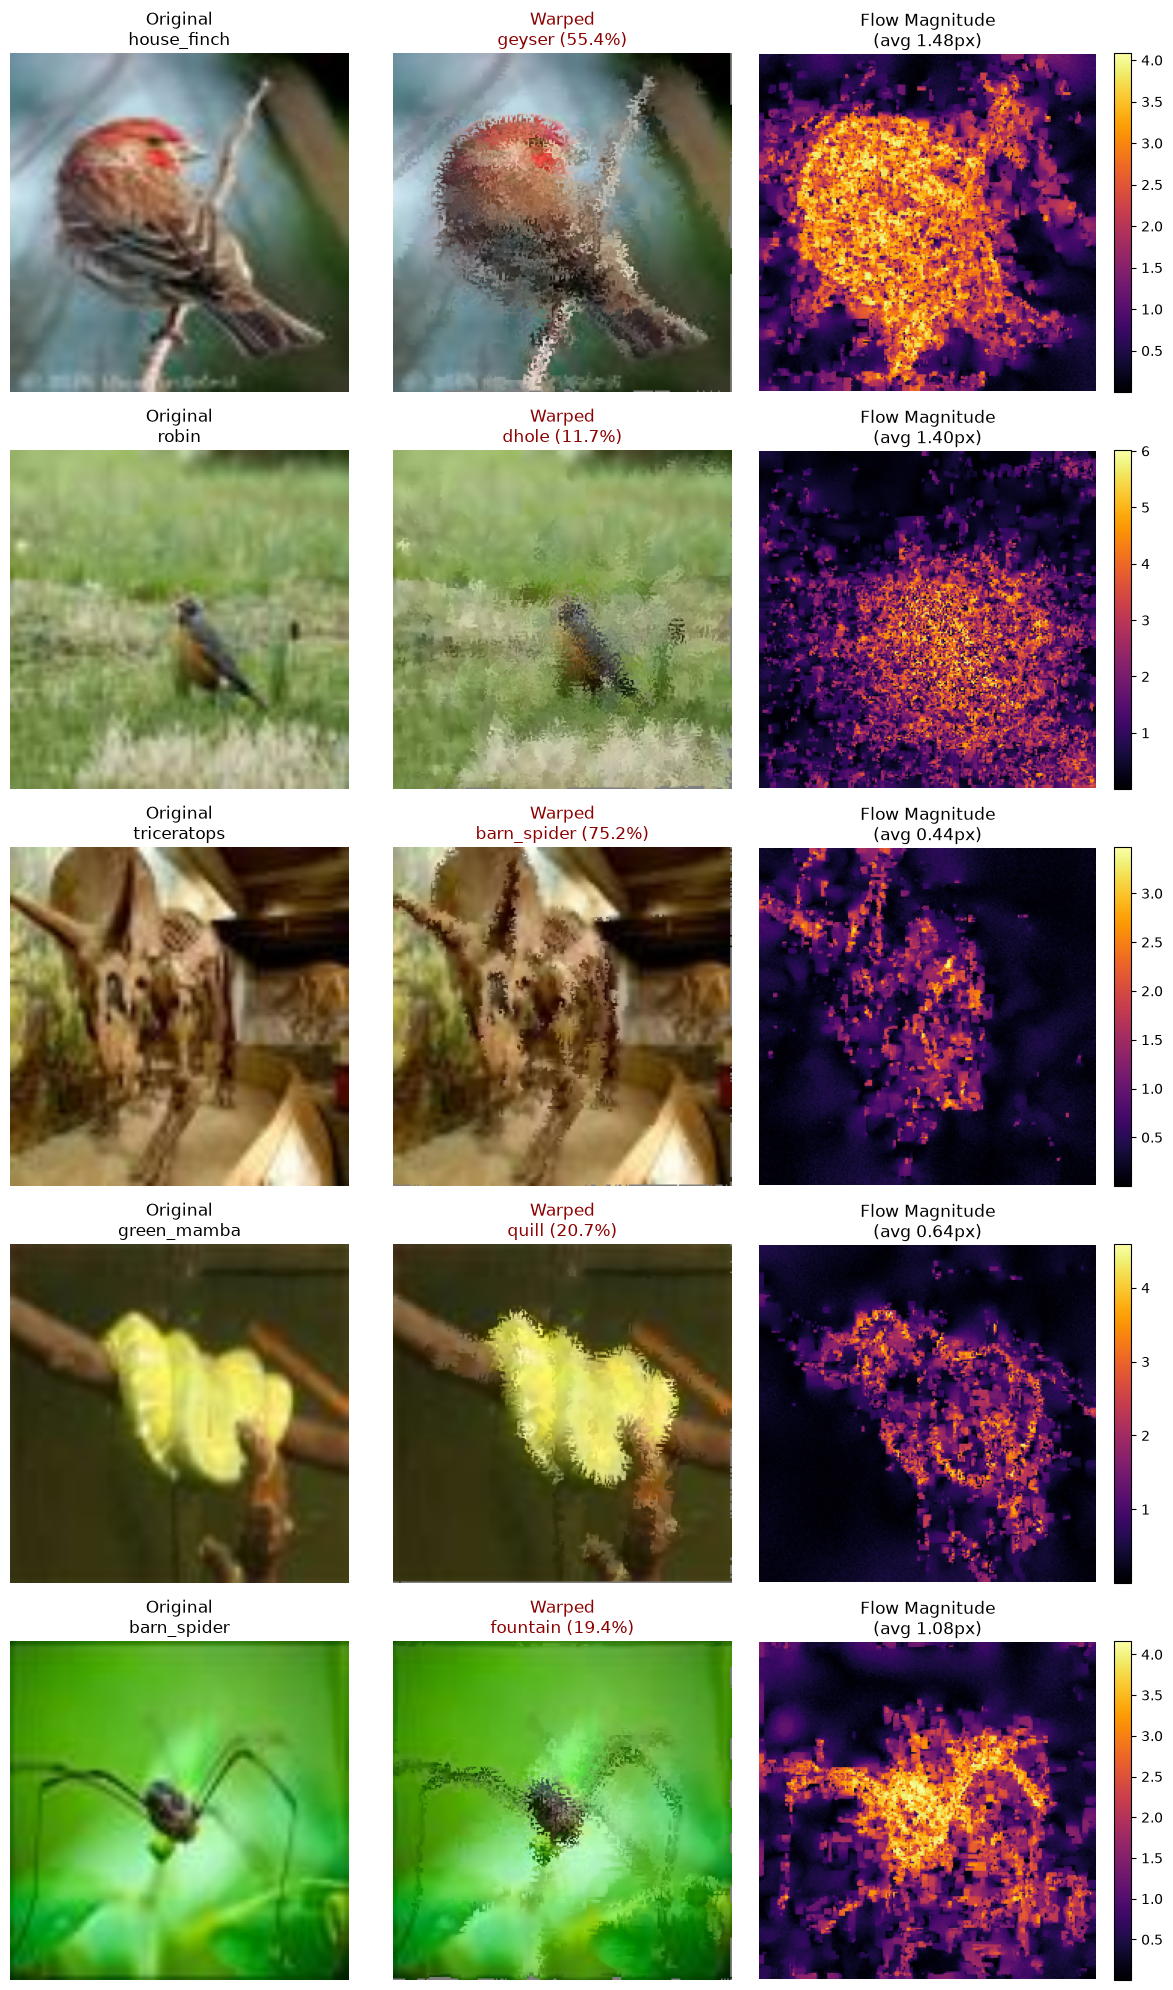

In [6]:
n = len(results)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = axes[None, :]

for row, r in enumerate(results):
    clean_display = np.clip((r['clean_img'] + 1) / 2, 0, 1)
    warped_display = np.clip((r['warped_img'] + 1) / 2, 0, 1)

    axes[row, 0].imshow(clean_display)
    axes[row, 0].set_title(f"Original\n{r['true_label']}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(warped_display)
    color = 'darkred' if r['success'] else 'black'
    axes[row, 1].set_title(f"Warped\n{r['adv_label']} ({r['adv_conf']*100:.1f}%)", color=color)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(r['flow_magnitude'], cmap='inferno')
    axes[row, 2].set_title(f"Flow Magnitude\n(avg {r['avg_displacement_px']:.2f}px)")
    axes[row, 2].axis('off')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

success_rate = 100 * sum(r['success'] for r in results) / len(results)
print(f"\n{sum(r['success'] for r in results)}/{len(results)} images successfully fooled ({success_rate:.0f}%)")
plt.tight_layout()
plt.show()